In [21]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [22]:
# LOAD DATA
df = pd.read_csv('solar_radiation.csv')
df['datetime'] = pd.to_datetime(df['UNIXTime'], unit='s')
df.set_index('datetime', inplace=True)
print(df.head())
print(df.shape)

                       UNIXTime                   Data      Time  Radiation  \
datetime                                                                      
2016-09-30 09:50:23  1475229023  9/29/2016 12:00:00 AM  23:50:23       1.21   
2016-09-30 09:45:26  1475228726  9/29/2016 12:00:00 AM  23:45:26       1.23   
2016-09-30 09:40:21  1475228421  9/29/2016 12:00:00 AM  23:40:21       1.21   
2016-09-30 09:35:24  1475228124  9/29/2016 12:00:00 AM  23:35:24       1.17   
2016-09-30 09:30:24  1475227824  9/29/2016 12:00:00 AM  23:30:24       1.21   

                     Temperature  Pressure  Humidity  WindDirection(Degrees)  \
datetime                                                                       
2016-09-30 09:50:23           48     30.46        58                  176.78   
2016-09-30 09:45:26           48     30.46        57                  158.75   
2016-09-30 09:40:21           48     30.46        60                  137.71   
2016-09-30 09:35:24           48     30.46    

In [43]:
#  TIME FEATURES
df['hour'] = df.index.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_of_year'] = df.index.dayofyear
df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

In [4]:
# CREATE LAG FEATURES
for lag in [1, 6, 12, 24]:
    df[f'Radiation_lag_{lag}'] = df['Radiation'].shift(lag)
df = df.dropna()
print(df.shape)

(32661, 21)


In [5]:
# DEFINE FEATURES AND TARGET
feature_cols = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 
                'Temperature', 'Humidity', 'Pressure', 
                'WindDirection(Degrees)', 'Speed',
                'Radiation_lag_1', 'Radiation_lag_6', 
                'Radiation_lag_12', 'Radiation_lag_24']

target_col = 'Radiation'

X = df[feature_cols]
y = df[target_col]
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (32661, 13)
Target shape: (32661,)


In [40]:
# SCALE DATA
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [41]:
#  TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)
print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 26128
Test size: 6533


In [42]:
#  CONVERT TO TENSORS
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

In [39]:
# DATALOADERS
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [10]:
#  BUILD NEURAL NETWORK
class SolarRadiationNN(nn.Module):
    def __init__(self, input_size):
        super(SolarRadiationNN, self).__init__()
        self.hidden1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.2)
        self.hidden2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.2)
        self.hidden3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.dropout3 = nn.Dropout(0.2)
        self.hidden4 = nn.Linear(32, 16)
        self.bn4 = nn.BatchNorm1d(16)
        self.output = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.bn1(self.hidden1(x)))
        x = self.dropout1(x)
        x = self.relu(self.bn2(self.hidden2(x)))
        x = self.dropout2(x)
        x = self.relu(self.bn3(self.hidden3(x)))
        x = self.dropout3(x)
        x = self.relu(self.bn4(self.hidden4(x)))
        x = self.output(x)
        return x

input_size = X_train.shape[1]
model = SolarRadiationNN(input_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)

SolarRadiationNN(
  (hidden1): Linear(in_features=13, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (hidden3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (hidden4): Linear(in_features=32, out_features=16, bias=True)
  (bn4): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)


In [11]:
# TRAIN THE NETWORK
epochs = 150
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item()
    
    train_losses.append(train_loss / len(train_loader))
    test_losses.append(test_loss / len(test_loader))
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.6f}, Test Loss: {test_losses[-1]:.6f}")

Epoch 20/150 - Train Loss: 0.002846, Test Loss: 0.002482
Epoch 40/150 - Train Loss: 0.002487, Test Loss: 0.002454
Epoch 60/150 - Train Loss: 0.002424, Test Loss: 0.002481
Epoch 80/150 - Train Loss: 0.002365, Test Loss: 0.002365
Epoch 100/150 - Train Loss: 0.002328, Test Loss: 0.002434
Epoch 120/150 - Train Loss: 0.002244, Test Loss: 0.002386
Epoch 140/150 - Train Loss: 0.002253, Test Loss: 0.002398


In [38]:
#  PREDICTIONS
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor).numpy()
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_actual = scaler_y.inverse_transform(y_test_tensor.numpy())

In [37]:
#  METRICS
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print("NEURAL NETWORK RESULTS")
print(f"MAE: {mae:.2f} W/m²")
print(f"RMSE: {rmse:.2f} W/m²")
print(f"R2 Score: {r2:.4f}")

NEURAL NETWORK RESULTS
MAE: 31.62 W/m²
RMSE: 78.46 W/m²
R2 Score: 0.9366


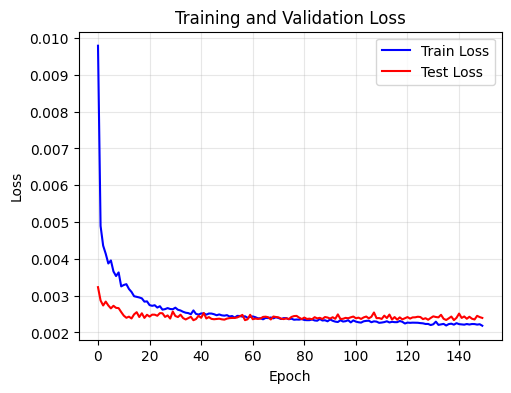

In [36]:
# PLOT TRAINING LOSS
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(test_losses, label='Test Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

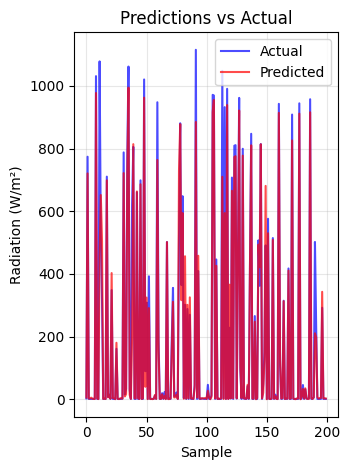

In [27]:
#  PLOT PREDICTIONS VS ACTUAL
plt.subplot(1, 2, 2)
plt.plot(y_actual[:200], label='Actual', color='blue', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted', color='red', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('Radiation (W/m²)')
plt.title('Predictions vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

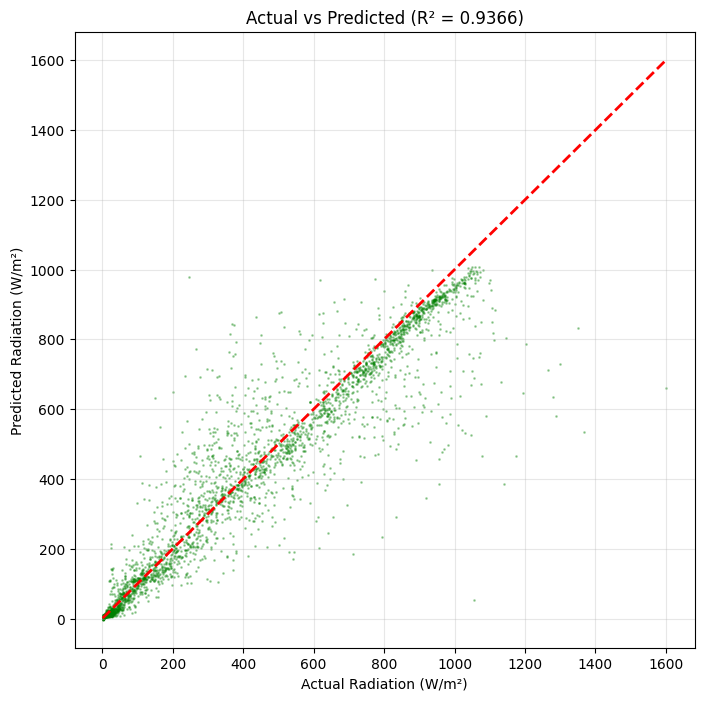

In [35]:
# SCATTER PLOT
plt.figure(figsize=(8, 8))
plt.scatter(y_actual, y_pred, alpha=0.3, s=1, color='green')
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', linewidth=2)
plt.xlabel('Actual Radiation (W/m²)')
plt.ylabel('Predicted Radiation (W/m²)')
plt.title(f'Actual vs Predicted (R² = {r2:.4f})')
plt.grid(True, alpha=0.3)
plt.show()

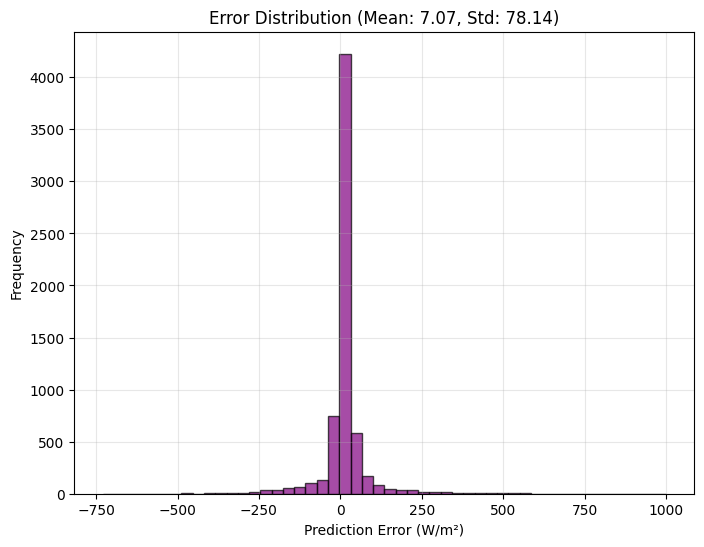

In [34]:
#  ERROR DISTRIBUTION
residuals = y_actual.flatten() - y_pred.flatten()
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='purple')
plt.xlabel('Prediction Error (W/m²)')
plt.ylabel('Frequency')
plt.title(f'Error Distribution (Mean: {residuals.mean():.2f}, Std: {residuals.std():.2f})')
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
# SAVE MODEL
torch.save(model.state_dict(), 'solar_nn.pth')
print("Model saved as solar_nn.pth")

Model saved as solar_nn.pth


In [32]:
#  SAVE SCALERS
import joblib
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
print("Scalers saved")

Scalers saved


In [33]:
#  SAVE FEATURE COLUMNS
import json
with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)
print("Feature columns saved")

Feature columns saved
